In [200]:
#!/usr/bin/env python
# coding: utf-8

"""
Title: Clean Clustered Xenium QC And Inspection
Date: 2026-06-29
Summary: Run QC and exploratory spatial plots from clean expression AnnData
objects that already contain BANKSY cluster labels and embeddings.
"""



'\nTitle: Clean Clustered Xenium QC And Inspection\nDate: 2026-06-29\nSummary: Run QC and exploratory spatial plots from clean expression AnnData\nobjects that already contain BANKSY cluster labels and embeddings.\n'

In [201]:


# ---------------------------------------------------------------------------- #
#                            01 - Xenium QC analysis                           #
# ---------------------------------------------------------------------------- #
## Date: April 2026
## Author: Nathalie Nataren




In [202]:


### Import packages
import anndata as ad
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq
import squidpy as sq
import matplotlib as mpl
from matplotlib import rc_context
import random
import dask
dask.config.set({"dataframe.query-planning": True})
 
import warnings
warnings.filterwarnings("ignore") 

# Note that BANKSY itself is deterministic, here the seeds affect the umap clusters and leiden partition
seed = 1234
np.random.seed(seed)
random.seed(seed)





In [203]:


# # ---------------------------------------------------------------------------- #
# #                              LOCAL TESTING BLOCK                             #
# # ---------------------------------------------------------------------------- #

# ## These values mirror config/01_clustering/vbct/small/CK_skin_res.json.
# ## Leave this block commented when using --config from Slurm/the shell.
# dataset_name = "CK_skin_res"
# pc_label = "30"
# pc_dims = [int(pc_label)]
# lambda_label = "0.20"
# lambda_list = [float(lambda_label)]
# res_label = ["0.70", "0.80", "0.90", "1.00"]
# res_label_list = res_label
# resolutions = [float(res) for res in res_label_list]
# plot_res_label = "1.00"
# nbr_weight_decay = "scaled_gaussian"
# coord_keys = ("x", "y", "xy")
# project = "vbct"
# raw_subdir = "vbct"
# res_str = "_".join(res_label_list)
# cluster_col = "labels_scaled_gaussian_pc30_nc0.20_r1.00"
# cluster_ann_col = f"{cluster_col}_ann"

# new_labels = {
#     "0": "Differentiated_melanoma_cells_(MITF+)_0",
#     "1": "Cancer_associated_fibroblasts_1",
#     "2": "M2-like_tumour_associated_macrophages_2",
#     "3": "Myofibroblasts_3",
#     "4": "Vascular_endothelial_cells_4",
#     "5": "C8+_T_cells_(ITGA4)_5",
# }




In [204]:


# --------------------- PARSE ARGUMENTS FROM JSON CONFIG --------------------- #

# This block of code feeds arguments to this python script from a config files found in /config

## Import argparse and json packages to read in variables from the per sample .json config files 
import argparse
import json


parser = argparse.ArgumentParser(prog="used to parse arguments from 01_QC_xenium_spatial_clean_clustered.py") # Initialise the parser
parser.add_argument("--config", type=str, help="Optional JSON config file for each Xenium sample", required=False) # This defines the flag and tells the script to look for a JSON config
# parse_known_args keeps notebook/kernel arguments from breaking local runs.
args, _unknown_args = parser.parse_known_args()

#"res_label": ["0.50", "0.60", "0.70", "0.80", "0.90", "1.00", "1.10"],

if args.config:
    with open(args.config) as f: # Opens the file path provided by the user
        cfg = json.load(f) # Converts the json config into a python dictionary called "cfg"
else:
    print("No --config supplied; using CK_skin_res local testing defaults.")
    cfg = {
        "project": "vbct",
        "raw_subdir": "vbct",
        "dataset_name": "CK_skin_res",
        "pc_label": "30",
        "lambda_label": "0.20",
        "res_label": ["0.50", "0.60", "0.70", "0.80", "0.90", "1.00", "1.10"],
        "plot_res_label": "0.70",
        "nbr_weight_decay": "scaled_gaussian",
        "coord_keys": ["x", "y", "xy"],
        "cluster_col": "labels_scaled_gaussian_pc30_nc0.20_r0.70",
        "new_labels": {
            "0": "Melanoma_Cell_or_Melanocyte_0",
            "1": "Fibroblast_1",
            "2": "Macrophage_2",
            "3": "Fibroblast_or_T_Cell_3",
            "4": "Melanoma_Cell_or_Melanocyte_4",
            "5": "Macrophage_5",
            "6": "Endothelial_Cell_6",
            "7": "Fibroblast_7",
        },
    }


## Set the dataset_name and related settings to use during this analysis by taking the argument values from the "cfg" dictionary read in from the JSON config
dataset_name = cfg["dataset_name"] # sample name
pc_label = cfg["pc_label"] # Label for the number of principal components used for the purpose of filenames
pc_dims = [int(pc_label)] # The number of principal components stored a list for analyses
lambda_label = cfg["lambda_label"] # File name label for Lambda setting, see comment below. 
lambda_list = [float(lambda_label)] # Lambda setting to tune BANKSY clustering, lambda = 0 is non-spatial, 0.2 is for cell typing, 0.8 if for domain segmentation 
res_label = cfg["res_label"] # BANKSY clustering resolution label(s) used in the clean clustered object filename
res_label_list = res_label if isinstance(res_label, list) else [res_label]
resolutions = [float(res) for res in res_label_list] # BANSY can take a list of resolutions and perform clustering at each which is saved in the BANKSY dictionary
plot_res_label = cfg.get("plot_res_label", res_label_list[-1]) # Resolution label to use for cluster-coloured QC plots
nbr_weight_decay = cfg["nbr_weight_decay"] # This parameter dictates how much neighbouring cells impact to the neighbourhood expression calculations. Using scaled gaussian, the 
# close neigbours contribute more and this decays as you move out to cells further away in the neighbourhood window. It is scaled for local cell density so that weighting doesn't change
# across regions if cells are pack more closely or loosely in different regions

coord_keys = tuple(cfg["coord_keys"]) # Keys to specify coordinate indexes in the anndata Object
project = cfg.get("project", "")
raw_subdir = cfg.get("raw_subdir", "")
res_str = "_".join(res_label_list)
plot_res_float = float(plot_res_label)
cluster_col = cfg.get("cluster_col", f"labels_scaled_gaussian_pc{pc_label}_nc{lambda_label}_r{plot_res_float:.2f}")
cluster_ann_col = f"{cluster_col}_ann"
new_labels = cfg.get("new_labels", {}) # These are the cluster labels for cell types




No --config supplied; using CK_skin_res local testing defaults.


In [205]:


# ---------------------------------------------------------------------------- #
#                                   SET PATHS                                  #
# ---------------------------------------------------------------------------- #
## Set file paths and read in xenium data

## Create a base path
base_dir = "data/xenium"
#base_dir = "/home/nnataren/Documents/PhD/Bioinformatics/Banksy_py_fork/Banksy_py/hpc"

## Create a path to the raw data e.g., unprocessed anndata files, if it does not already exist
raw_path = os.path.join(base_dir, "raw_data", raw_subdir)

if not os.path.isdir(raw_path):
    os.makedirs(raw_path)
    print(f"Directory '{raw_path} successfully.")
    
else:
    print(f"Directory '{raw_path} exists.")

## Create path for processed data e.g., the pre-clustered but unfiltered anndata files, if it does not already exist
processed_path = os.path.join(base_dir, "processed", project, dataset_name)

if not os.path.isdir(processed_path):
    os.makedirs(processed_path)
    print(f"Directory '{processed_path}' created successfully.")
    
else:
    print(f"Directory '{processed_path}' already exists.")

## Create a path for output data, if it does not already exist
output_path = os.path.join(base_dir, "output", project, dataset_name)

if not os.path.isdir(output_path):
    os.makedirs(output_path)
    print(f"Directory '{output_path}' created successfully.")
    
else:
    print(f"Directory '{output_path}' already exists.")

## Construct the clean clustered AnnData path from the processed sample directory.
clean_adata_path = os.path.join(
    processed_path,
    f"adata_expression_clean_{dataset_name}_with_banksy_clusters_{res_str}.h5ad"
)

## Create a path for QC results, if it does not already exist
qc_path = os.path.join(base_dir, "output", project, "QC_testing", dataset_name)

if not os.path.isdir(qc_path):
    os.makedirs(qc_path)
    print(f"Directory '{qc_path}' created successfully.")
else:
    print(f"Directory '{qc_path}' already exists.")




Directory 'data/xenium/raw_data/vbct exists.
Directory 'data/xenium/processed/vbct/CK_skin_res' already exists.
Directory 'data/xenium/output/vbct/CK_skin_res' already exists.
Directory 'data/xenium/output/vbct/QC_testing/CK_skin_res' already exists.


In [206]:


# ---------------------------------------------------------------------------- #
#                                 LOAD ANNDATA                                 #
# ---------------------------------------------------------------------------- #

## Read in the clean expression AnnData object with BANKSY cluster labels already stored in .obs.
adata_clean = ad.read_h5ad(clean_adata_path)
print(f"Clean clustered AnnData object for {dataset_name} successfully read in from {clean_adata_path}.")

if cluster_col not in adata_clean.obs.columns:
    raise KeyError(f"{cluster_col} was not found in adata_clean.obs. Available columns: {list(adata_clean.obs.columns)}")

## Use the same object for QC masks and cluster-coloured plots.
adata = adata_clean

## Create 'xy' spatial coordinates from adata.obs if they are not already present.
if 'xy' not in adata_clean.obsm:
    adata_clean.obsm['xy'] = np.vstack([adata_clean.obs['x'], adata_clean.obs['y']]).T

## Scanpy plotting helpers expect generic X_umap/X_pca keys. Keep the
## explicit BANKSY keys, but add generic aliases for this QC script.
banksy_umap_key = f"X_umap_{nbr_weight_decay}_pc{pc_label}_nc{lambda_label}"
if banksy_umap_key in adata_clean.obsm and "X_umap" not in adata_clean.obsm:
    adata_clean.obsm["X_umap"] = adata_clean.obsm[banksy_umap_key]
    print(f"Aliased {banksy_umap_key} to adata_clean.obsm['X_umap']")

banksy_pca_key = f"X_pca_{nbr_weight_decay}_pc{pc_label}_nc{lambda_label}"
if banksy_pca_key in adata_clean.obsm and "X_pca" not in adata_clean.obsm:
    adata_clean.obsm["X_pca"] = adata_clean.obsm[banksy_pca_key]
    print(f"Aliased {banksy_pca_key} to adata_clean.obsm['X_pca']")




Clean clustered AnnData object for CK_skin_res successfully read in from data/xenium/processed/vbct/CK_skin_res/adata_expression_clean_CK_skin_res_with_banksy_clusters_0.50_0.60_0.70_0.80_0.90_1.00_1.10.h5ad.
Aliased X_umap_scaled_gaussian_pc30_nc0.20 to adata_clean.obsm['X_umap']
Aliased X_pca_scaled_gaussian_pc30_nc0.20 to adata_clean.obsm['X_pca']


In [207]:


processed_path




'data/xenium/processed/vbct/CK_skin_res'

In [208]:


adata_clean.obsm




AxisArrays with keys: X_pca_scaled_gaussian_pc30_nc0.20, X_umap_scaled_gaussian_pc30_nc0.20, spatial, xy, X_umap, X_pca

In [209]:


# ---------------------------------------------------------------------------- #
#                            FILTER ZERO COUNT CELLS                           #
# ---------------------------------------------------------------------------- #

## Filter out cells with zero counts while keeping the clean object as the only working object.
adata_clean = adata_clean[adata_clean.obs['nCount_Xenium'] > 0].copy()
adata = adata_clean




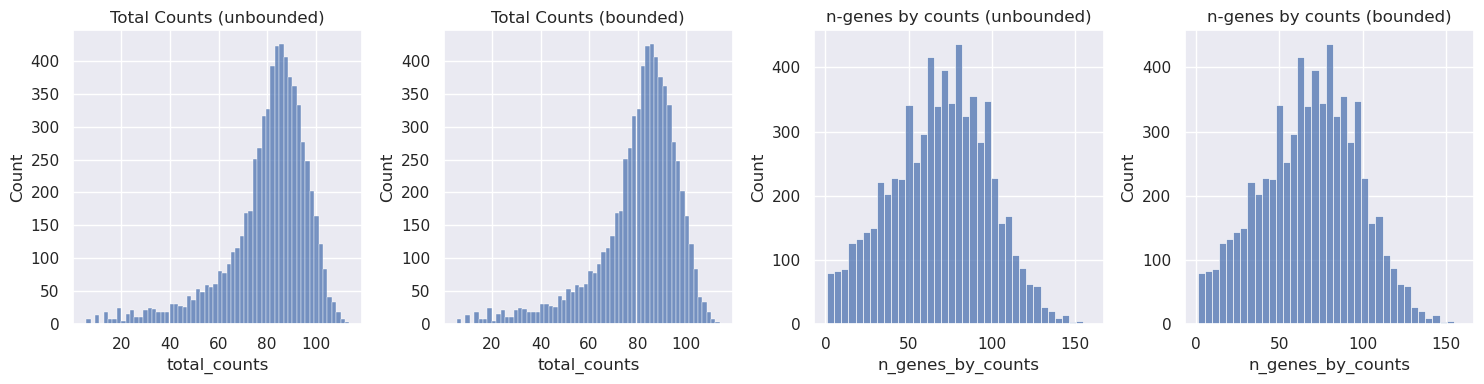

In [210]:


# ---------------------------------------------------------------------------- #
#                          CALCULATE SCANPY QC METRICS                         #
# ---------------------------------------------------------------------------- #

## Calculate some basic scanpy quality metric for plotting
adata.var_names_make_unique() # This ensure all probe names are unique
sc.pp.calculate_qc_metrics(adata, 
                           log1p=True, 
                           inplace=True,
                           percent_top=[10,20]
                           )


from banksy_utils.plot_utils import plot_qc_hist, plot_cell_positions
# bin options for fomratting histograms
# Here, we set 'auto' for 1st figure, 'auto' bins for 2nd figure and so on
hist_bin_options = ['auto', 'auto', 'auto', 'auto']

plot_qc_hist(adata, 
         total_counts_cutoff = 200, # for visualization
         n_genes_high_cutoff = 1000, # for visualization
         n_genes_low_cutoff = 0, # for visualization
         bin_options = hist_bin_options)

plt.savefig(os.path.join(qc_path, f"banksy_counts_and_genes_plot_{dataset_name}.png"), dpi =300, bbox_inches='tight')
plt.show()




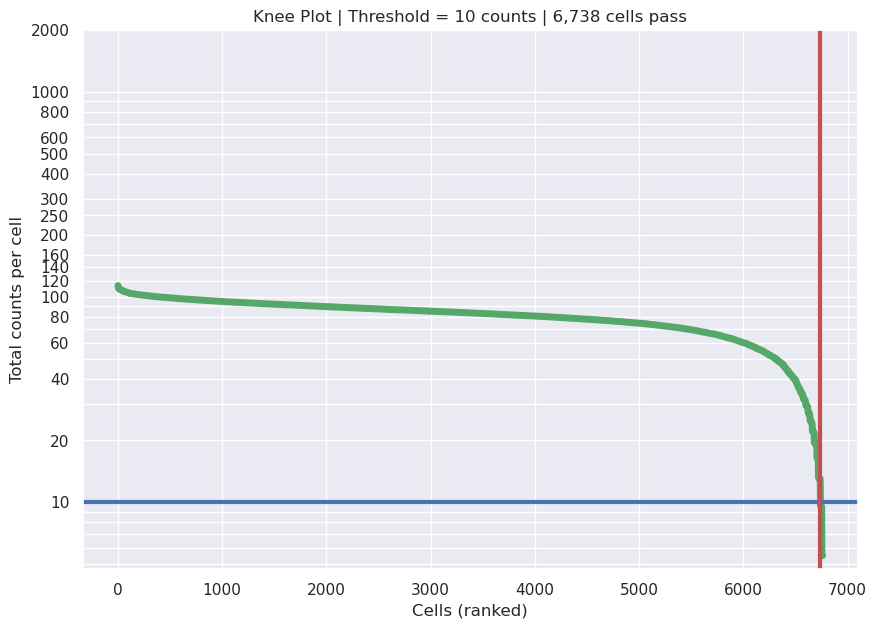

Cells passing threshold of 10 counts: 6,738 / 6,760 (99.7%)


In [211]:


# ---------------------------------------------------------------------------- #
#                FILTER 1 - MINIMUM NUMBER OF TRANSCRIPTS FILTER               #
# ---------------------------------------------------------------------------- #

### Plot knee plot (log10 transcripts per cell)
## Knee plot code adapted from https://pachterlab.github.io/kallistobustools/tutorials/kb_getting_started/python/kb_intro_2_python/

# ------------------- Set the minimum transcript threshold ------------------- #
threshold = 10
knee = np.sort((np.array(adata.X.sum(axis=1))).flatten())[::-1]

## Plot the knee plot
cell_set = np.arange(len(knee))
num_cells = (knee > threshold).sum()
fig, ax = plt.subplots(figsize=(10, 7))

ax.semilogy(knee, linewidth =5, color="g")
ax.axhline(y=threshold, linewidth=3, color="b")
ax.axvline(x=num_cells, linewidth=3, color="r")

ax.set_xlabel("Cells (ranked)")
ax.set_ylabel("Total counts per cell")

ax.set_yticks([10, 20, 40, 60, 80, 100, 120, 140, 160, 200, 250, 300, 400, 500, 600, 800, 1000, 2000])
ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())

plt.grid(True, which="both")
plt.title(f"Knee Plot | Threshold = {threshold} counts | {num_cells:,} cells pass")
plt.savefig(os.path.join(qc_path, f"transcript_knee_plot_{dataset_name}.png"), dpi =300, bbox_inches='tight')
plt.show()

print(f"Cells passing threshold of {threshold} counts: {num_cells:,} / {len(knee):,} ({num_cells/len(knee)*100:.1f}%)")




In [212]:


# ---------------- Apply the minimum transcripts per cell mask --------------- #

## Apply a mask to retrieve cells that don't pass the filter
mask = adata.obs['nCount_Xenium'] <= threshold

# Turn the masked cells into a data frame
mask.to_frame()
mask_cells = mask.reset_index()
mask_cells = mask_cells.rename(columns={"index":"cell_id", "nCount_Xenium" : "min_trans_passed"})

# # Filter for the poor cells and keep these ids for future plotting
# min_trans_filter_failed = mask_cells[mask_cells['min_trans_passed']]

# Put results for the cells passing the threshold into the object directly
adata.obs['min_trans_passed'] = adata.obs['nCount_Xenium'] > threshold #True = passed




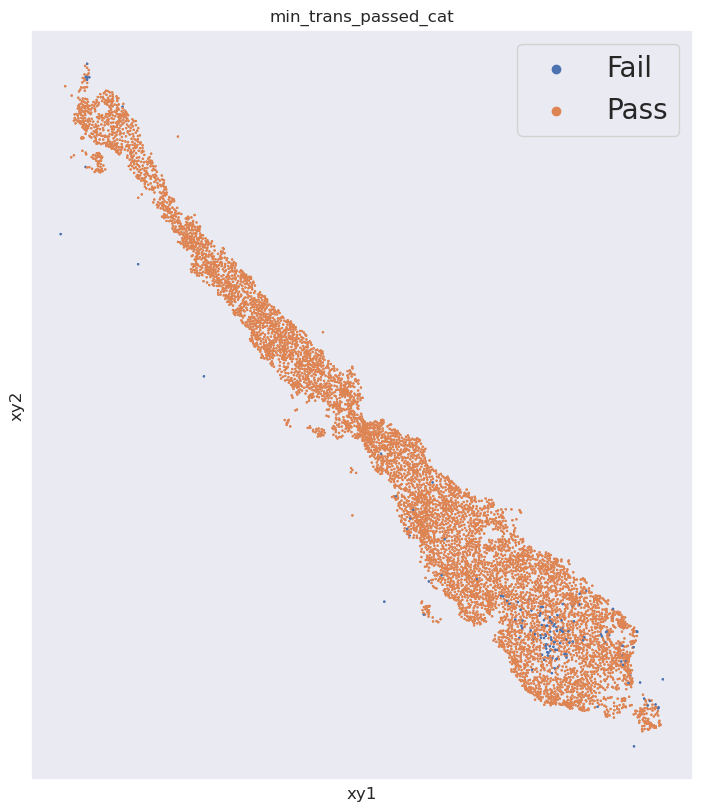

Saving tissue_spatial_scatter_min_counts_threshold_passed_cells_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [213]:


# ------------------- Plot location of poor cells on tissue ------------------ #
adata.obs["min_trans_passed_cat"] = adata.obs["min_trans_passed"].map({True: "Pass", False: "Fail"}).astype("category")

with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="min_trans_passed_cat",
        shape=None,
        size=2,
        img=False
    )
    plt.legend(fontsize=20)


# Save the figure
plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_min_counts_threshold_passed_cells_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 
print(f"Saving tissue_spatial_scatter_min_counts_threshold_passed_cells_{dataset_name}.png to {qc_path}" )                     




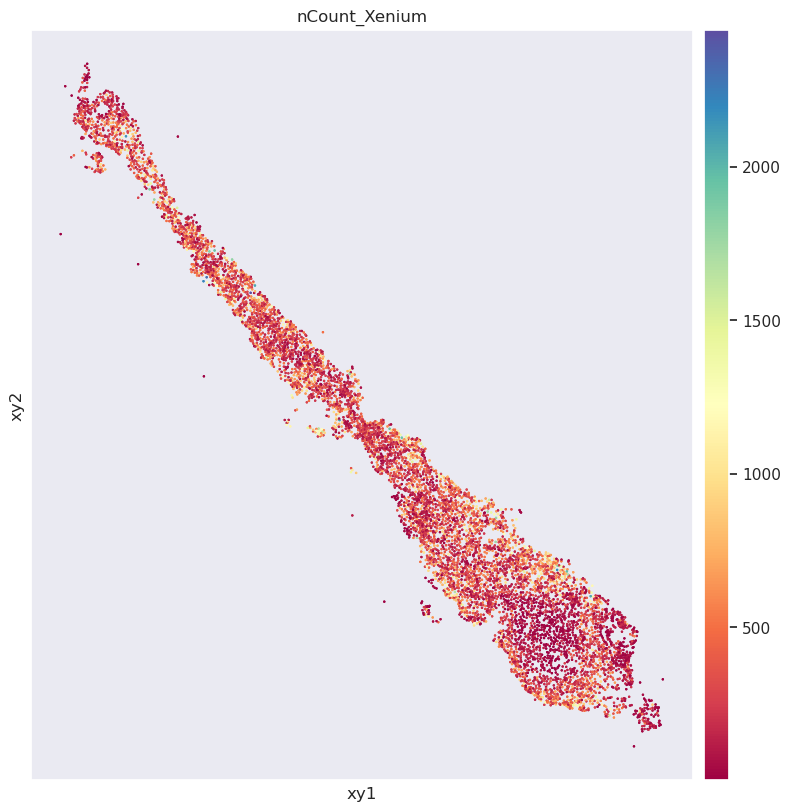

In [214]:


# -------------- Plot of total transripts per cell across sample ------------- #
# gist_stern, dynamic vmax threshold
with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="nCount_Xenium",
        shape=None,
        size=2,
        img=False,
        vmax = adata.obs['nCount_Xenium'].max(),
        cmap="Spectral"
    )

## Save the figure
plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_transcripts_qc_dynamic_range_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 




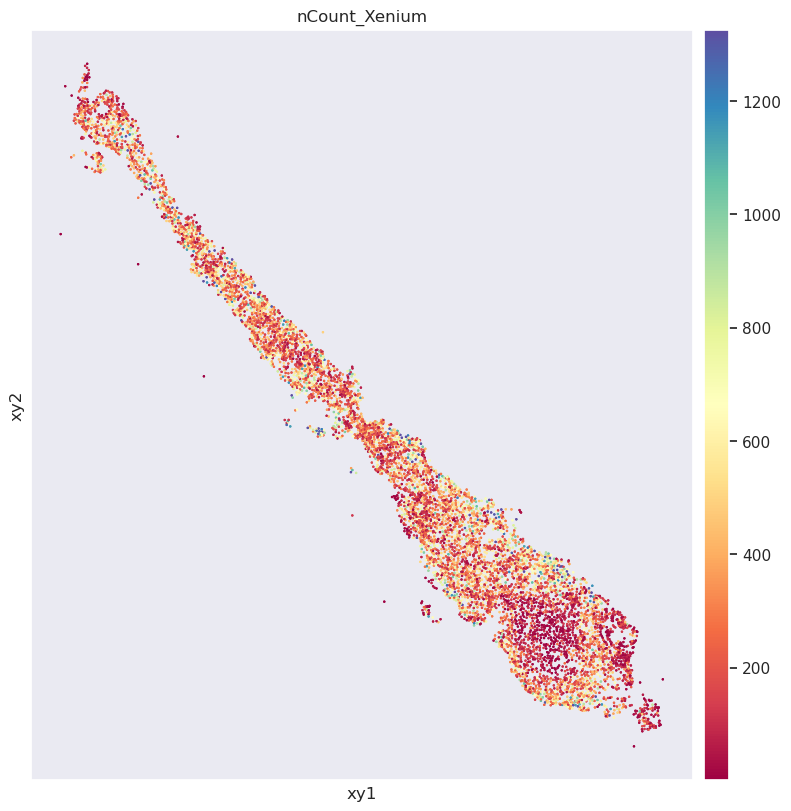

In [215]:


# -------------- Plot of total transripts per cell across sample ------------- #
# vmax set to the 99th percentile of transcript counts
with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="nCount_Xenium",
        shape=None,
        size=2,
        img=False,
        vmax = adata.obs['nCount_Xenium'].quantile(0.99),
        #cmap="gist_stern"
        #cmap="gist_rainbow"
        #cmap="rainbow"
        cmap="Spectral"
    )

plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_transcripts_qc_quantile_99_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 




In [216]:


# ---------------------------------------------------------------------------- #
#                         EXPORT ADATA.X MATRIX TO .CSV                        #
# ---------------------------------------------------------------------------- #

## Convert the the whole adata.X into a matrix and export to .csv
pd.DataFrame(
    adata.X.toarray(),  # convert sparse matrix to dense
    index=adata.obs_names, 
    columns=adata.var_names
).to_csv(os.path.join(qc_path, f"adata_X_inspection_{dataset_name}.csv"))

obs= adata.obs
obs.to_csv(os.path.join(qc_path, f"obs_{dataset_name}.csv"))




In [217]:


# ---------------------------------------------------------------------------- #
#                             HIGH COUNT GENES PLOT                            #
# ---------------------------------------------------------------------------- #

# ----------- Calculate the sum of a genes counts across all cells ----------- #
## Sort the adata.obs by total_counts to see which genes have exceedingly high counts
obs = adata.obs
obs.sort_values(by=["transcript_counts"], ascending=False)
obs.to_csv(os.path.join(qc_path, f"obs_{dataset_name}.csv"))
print("All files saved to:", qc_path)




All files saved to: data/xenium/output/vbct/QC_testing/CK_skin_res


In [218]:


# # ----------- Calculate the total counts for genes across all cells ---------- #
# adata_X = pd.DataFrame(
#     adata.X.toarray(),
#     index=adata.obs_names,
#     columns=adata.var_names
# )

# gene_total_object = adata_X.sum(axis=0)


# top_genes_object = gene_total_object.sort_values(ascending=False).reset_index()
# top_genes_object.columns = ['gene', 'total_counts']
# top_genes_object.to_csv(os.path.join(qc_path, f"gene_counts_across_all_cells_{dataset_name}_test.csv"))




In [219]:


# # --------------------------- Plot the top 50 genes -------------------------- #
# top_genes_object = top_genes_object.iloc[0:51]

# plt.figure(figsize=(25, 5))
# plt.scatter(top_genes_object['gene'], top_genes_object['total_counts'])
# plt.xticks(rotation=90)
# plt.tight_layout()

# plt.savefig(
#     os.path.join(qc_path, f"top_50_genes_by_counts_{dataset_name}.png"),
#     dpi=300,
#     bbox_inches='tight'
#     )




In [220]:


# ---------------------------------------------------------------------------- #
#                FILTER 2 - MAXIMUM NUMBER OF TRANSCRIPTS FILTER               #
# ---------------------------------------------------------------------------- #

# ---- Maximum transcripts per cell mask for cells with top 2% transcripts --- #
raw_counts = adata.obs['nCount_Xenium']
quantile = np.quantile(raw_counts, 0.98)
quantile_masked_cells = raw_counts >= quantile
#quantile_masked_cells = quantile_masked_cells.to_frame()
quantile_masked_cells = quantile_masked_cells.reset_index()
#max_trans_threshold_passed = quantile_masked_cells.rename(columns={"index" : "cell_id", "nCount_Xenium" : "max_transcripts_passed"})
max_trans_threshold_passed = quantile_masked_cells.rename(columns={"nCount_Xenium" : "max_transcripts_passed"})
max_trans_threshold_passed = max_trans_threshold_passed.set_index("index")
# Store the results for the max_rans_filter into the object .obs
adata.obs['max_trans_threshold_passed'] = max_trans_threshold_passed['max_transcripts_passed']




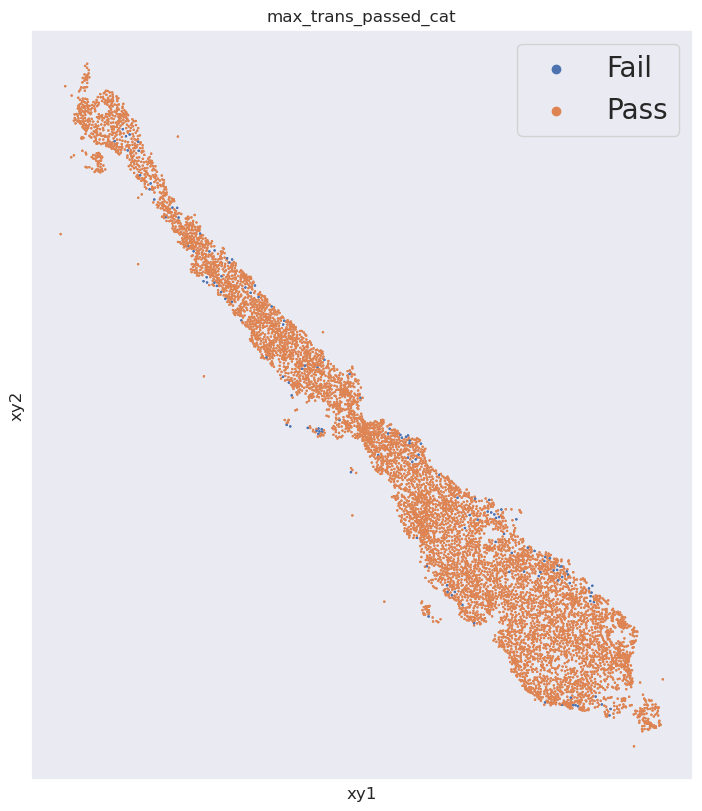

Saving tissue_spatial_scatter_max_counts_threshold_passed_cells_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [221]:


# ------------------- Plot location of poor cells on tissue ------------------ #
adata.obs["max_trans_passed_cat"] = adata.obs["max_trans_threshold_passed"].map({True: "Fail", False: "Pass"}).astype("category")

with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="max_trans_passed_cat",
        shape=None,
        size=2,
        img=False
    )
    plt.legend(fontsize=20)


# Save the figure
plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_max_counts_threshold_passed_cells_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 
print(f"Saving tissue_spatial_scatter_max_counts_threshold_passed_cells_{dataset_name}.png to {qc_path}" )                     




In [222]:

# ---------------------------------------------------------------------------- #
#                  USE CLEAN CLUSTERED ANNDATA FOR CLUSTER QC                  #
# ---------------------------------------------------------------------------- #

## The clean object already contains BANKSY cluster labels in .obs, so this
## script does not read old BANKSY spatial objects or rebuild clusters from saved BANKSY outputs.
adata_clean = adata
adata_clean.obs[cluster_col] = adata_clean.obs[cluster_col].astype(str)

if new_labels:
    adata_clean.obs[cluster_ann_col] = adata_clean.obs[cluster_col].map(new_labels)
    adata_clean.obs[cluster_ann_col] = adata_clean.obs[cluster_ann_col].fillna(adata_clean.obs[cluster_col]).astype("category")
else:
    adata_clean.obs[cluster_ann_col] = adata_clean.obs[cluster_col].astype("category")




In [223]:
cluster_col

'labels_scaled_gaussian_pc30_nc0.20_r0.70'

In [224]:
adata_clean.obs

,sample_name,x,y,cell_area,nucleus_area,transcript_counts,total_counts,nucleus_count,control_probe_counts,genomic_control_counts,...,n_genes_by_counts,log1p_n_genes_by_counts,log1p_total_counts,pct_counts_in_top_10_genes,pct_counts_in_top_20_genes,min_trans_passed,min_trans_passed_cat,max_trans_threshold_passed,max_trans_passed_cat,labels_scaled_gaussian_pc30_nc0.20_r0.70_ann
aaabjldc-1,CK_skin_res,134.886642,638.876343,205.099695,121.831567,765,75.570930,1,0,0,...,90,4.510860,4.338218,35.229293,54.083176,True,Pass,False,Pass,Melanoma_Cell_or_Melanocyte_0
aaaenhao-1,CK_skin_res,238.324539,723.201538,167.394225,108.239535,771,95.937561,1,0,0,...,110,4.709530,4.574067,24.987841,41.506117,True,Pass,False,Pass,8
aaamkopm-1,CK_skin_res,190.484802,734.506287,78.300940,49.220314,287,78.399803,1,0,0,...,67,4.219508,4.374496,30.648346,50.527412,True,Pass,False,Pass,Melanoma_Cell_or_Melanocyte_0
aaamomnk-1,CK_skin_res,178.695374,720.238647,74.191721,52.336096,270,76.257263,1,0,0,...,65,4.189655,4.347141,34.255473,54.427499,True,Pass,False,Pass,Melanoma_Cell_or_Melanocyte_0
aabbmchc-1,CK_skin_res,237.545151,570.459290,41.453439,NaN,60,64.604218,0,0,0,...,33,3.526361,4.183640,40.092900,67.681251,True,Pass,False,Pass,Fibroblast_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oilpgnhc-1,CK_skin_res,1729.905884,2174.161865,23.977970,23.977970,72,78.186142,1,0,0,...,45,3.828641,4.371801,30.128044,53.216559,True,Pass,False,Pass,Endothelial_Cell_6
oimpaeli-1,CK_skin_res,1723.013306,2174.650146,51.387814,12.417969,57,69.945251,1,0,0,...,36,3.610918,4.261909,34.535155,62.317766,True,Pass,False,Pass,Macrophage_5
oinbdjin-1,CK_skin_res,1776.754517,2219.642090,16.843282,16.843282,24,40.420319,1,0,0,...,15,2.772589,3.723772,70.384946,100.000000,True,Pass,False,Pass,Melanoma_Cell_or_Melanocyte_0
oinkodgh-1,CK_skin_res,1770.702393,2221.114258,28.990314,12.824375,58,66.400787,1,0,0,...,35,3.583519,4.210657,38.506410,63.103847,True,Pass,False,Pass,Fibroblast_or_T_Cell_3


In [225]:
adata_clean.obs.columns.tolist()

['sample_name',
 'x',
 'y',
 'cell_area',
 'nucleus_area',
 'transcript_counts',
 'total_counts',
 'nucleus_count',
 'control_probe_counts',
 'genomic_control_counts',
 'control_codeword_counts',
 'unassigned_codeword_counts',
 'deprecated_codeword_counts',
 'segmentation_method',
 'nCount_Xenium',
 'nFeature_Xenium',
 'labels_scaled_gaussian_pc30_nc0.20_r0.50',
 'labels_scaled_gaussian_pc30_nc0.20_r0.60',
 'labels_scaled_gaussian_pc30_nc0.20_r0.70',
 'labels_scaled_gaussian_pc30_nc0.20_r0.80',
 'labels_scaled_gaussian_pc30_nc0.20_r0.90',
 'labels_scaled_gaussian_pc30_nc0.20_r1.00',
 'labels_scaled_gaussian_pc30_nc0.20_r1.10',
 'n_genes_by_counts',
 'log1p_n_genes_by_counts',
 'log1p_total_counts',
 'pct_counts_in_top_10_genes',
 'pct_counts_in_top_20_genes',
 'min_trans_passed',
 'min_trans_passed_cat',
 'max_trans_threshold_passed',
 'max_trans_passed_cat',
 'labels_scaled_gaussian_pc30_nc0.20_r0.70_ann']

In [226]:
adata_clean.obs["nCount_Xenium"].sum()

2115819

In [227]:
# ---------------------------------------------------------------------------- #
#                   FILTER 3 - NEGATIVE CONTROL PROBE FILTER                   #
# ---------------------------------------------------------------------------- #

In [228]:
## Calculate the percentage of negative controls per total transcripts for each cell
adata_clean.obs["neg_probe_pct_of_gene_plus_neg_probe"] = (adata_clean.obs["control_probe_counts"] / (adata_clean.obs["nCount_Xenium"] + adata_clean.obs["control_probe_counts"])) * 100

## Calculate the transcripts detected per um^2 of cell area
adata_clean.obs["gene_transcripts_per_um2"] = (adata_clean.obs["nCount_Xenium"] / adata_clean.obs["cell_area"])

adata_clean.obs["neg_probe_pct_of_gene_plus_neg_probe"] = adata_clean.obs["neg_probe_pct_of_gene_plus_neg_probe"]
adata_clean.obs["gene_transcripts_per_um2"] = adata_clean.obs["gene_transcripts_per_um2"]


<Axes: xlabel='control_probe_counts', ylabel='nCount_Xenium'>

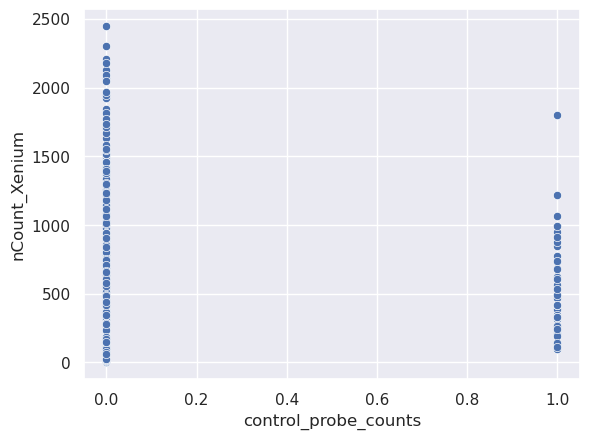

In [229]:
## Negative control scatter plot

sns.set_theme(style="darkgrid")

sns.scatterplot(
    data = adata_clean.obs,
    x= "control_probe_counts",
    y= "nCount_Xenium"
    )



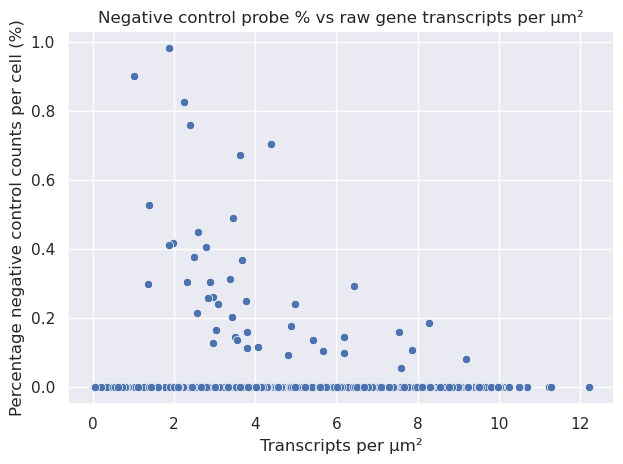

Saving Negative_Control_%_vs_Transcript_Density_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [230]:
## percentage of negative controls vs transcripts detected per um^2

sns.set_theme(style="darkgrid")

sns.scatterplot(
    data = adata_clean.obs,
    x= "gene_transcripts_per_um2",
    y= "neg_probe_pct_of_gene_plus_neg_probe"    
    )

plt.title("Negative control probe % vs raw gene transcripts per µm²")
plt.ylabel("Percentage negative control counts per cell (%)")
plt.xlabel("Transcripts per µm²")

plt.tight_layout()
# Save the figure
plt.savefig(
    os.path.join(qc_path, f"Negative_Control_%_vs_Transcript_Density_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 
print(f"Saving Negative_Control_%_vs_Transcript_Density_{dataset_name}.png to {qc_path}")    

In [231]:
## Read in transcript parquet to get raw negative control probe counts
tx = pd.read_parquet(os.path.join(raw_path, "transcript_parquet", f"{dataset_name}"))
tx["codeword_category"].value_counts()

codeword_category
predesigned_gene             2671692
custom_gene                   296979
unassigned_codeword             5349
negative_control_codeword       1100
negative_control_probe           543
Name: count, dtype: int64

In [232]:
##subset transcripts tx to only those cells present in the adata_clean object
adata_cells = set(adata_clean.obs_names.astype(str))
tx["cell_id"] = tx["cell_id"].astype(str)

tx_subset = tx[tx["cell_id"].isin(adata_cells)].copy()

tx_subset.to_parquet(os.path.join(output_path,"transcripts_subset_to_adatat_clean_cells.parquet"))

In [233]:
print("Original transcripts:", len(tx))
print("Subset transcripts:", len(tx_subset))
print("Unique transcript cell IDs:", tx_subset["cell_id"].nunique())
print("AnnData cells:", adata_clean.n_obs)


Original transcripts: 2975663
Subset transcripts: 2440683
Unique transcript cell IDs: 6760
AnnData cells: 6760


In [234]:
neg_tx = tx_subset[tx_subset["codeword_category"] == "negative_control_probe"]
neg_tx

,transcript_id,cell_id,overlaps_nucleus,feature_name,x_location,y_location,z_location,qv,fov_name,nucleus_distance,codeword_index,codeword_category,is_gene
35085,281474976785704,bflhgpce-1,0,NegControlProbe_00025,166.515625,286.796875,16.375000,19.50,F7,0.718750,339,negative_control_probe,False
35086,281474976874807,bfohlnmi-1,0,NegControlProbe_00024,124.203125,444.812500,12.562500,15.00,F7,1.250000,342,negative_control_probe,False
35087,281474976786725,bfggnhen-1,0,NegControlProbe_00003,144.062500,320.687500,17.656250,17.25,F7,0.406250,380,negative_control_probe,False
35088,281474976721812,dcidieig-1,0,NegControlProbe_00002,238.078125,498.125000,11.328125,16.75,F7,3.687500,386,negative_control_probe,False
87680,281474976836690,nlkklape-1,0,NegControlProbe_00013,87.109375,668.984375,13.218750,37.75,F7,1.515625,371,negative_control_probe,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2973542,281517926404484,hpedcbhl-1,0,NegControlProbe_00024,2601.250000,3001.609375,22.343750,17.25,J11,1.750000,342,negative_control_probe,False
2973543,281517926499329,hnkkonho-1,0,NegControlProbe_00024,2665.625000,3192.953125,25.234375,17.25,J11,2.046875,342,negative_control_probe,False
2973544,281517926450390,ihlnhhdg-1,0,NegControlProbe_00022,2523.718750,3195.203125,27.078125,16.75,J11,3.968750,343,negative_control_probe,False
2973545,281517926410333,ihlnhhdg-1,0,NegControlProbe_00017,2512.796875,3192.453125,27.531250,11.75,J11,0.859375,355,negative_control_probe,False


In [235]:
cluster_ann_col

'labels_scaled_gaussian_pc30_nc0.20_r0.70_ann'

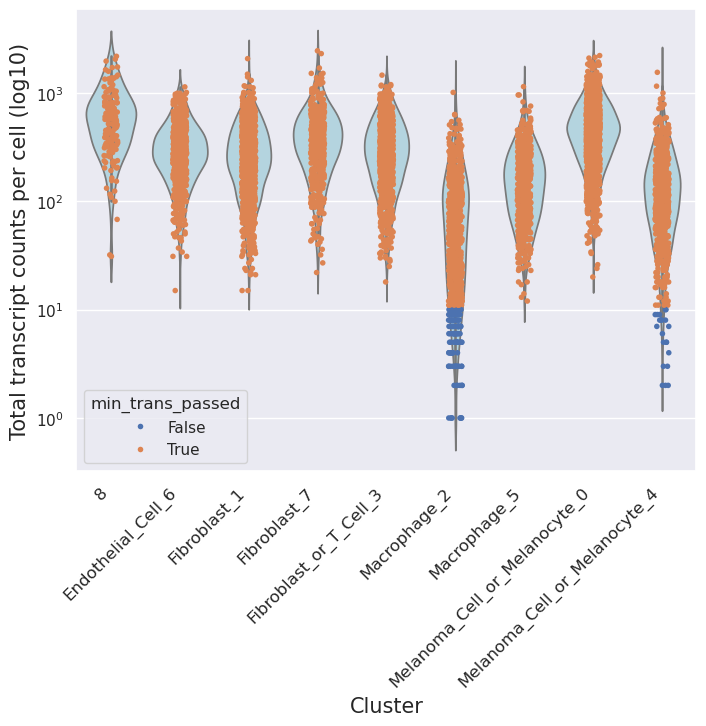

In [236]:


# ---------------------------------------------------------------------------- #
#    CLUSTER LEVEL VIOLIN PLOTS OF MINIMUM TRANSCRIPT COUNT THRESHOLD CELLS    #
# ---------------------------------------------------------------------------- #

obs = adata_clean.obs
cell_label = cluster_ann_col

plt.figure(figsize=(8, 6))
sns.violinplot(data=obs, y=obs["nCount_Xenium"],  x=obs[cluster_ann_col], log_scale=10, color="lightblue")

sns.stripplot(data=obs, y=obs["nCount_Xenium"], x=obs[cluster_ann_col], hue =obs["min_trans_passed"], size=4)

plt.xlabel("Cluster", fontsize=15)
plt.ylabel("Total transcript counts per cell (log10)", fontsize=15)
plt.xticks(rotation=45, fontsize=12, ha='right', va='top')


plt.savefig(
    os.path.join(qc_path, f"threshold_passed_cells_per_cluster_violin_plot_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )




In [ ]:


adata.obs




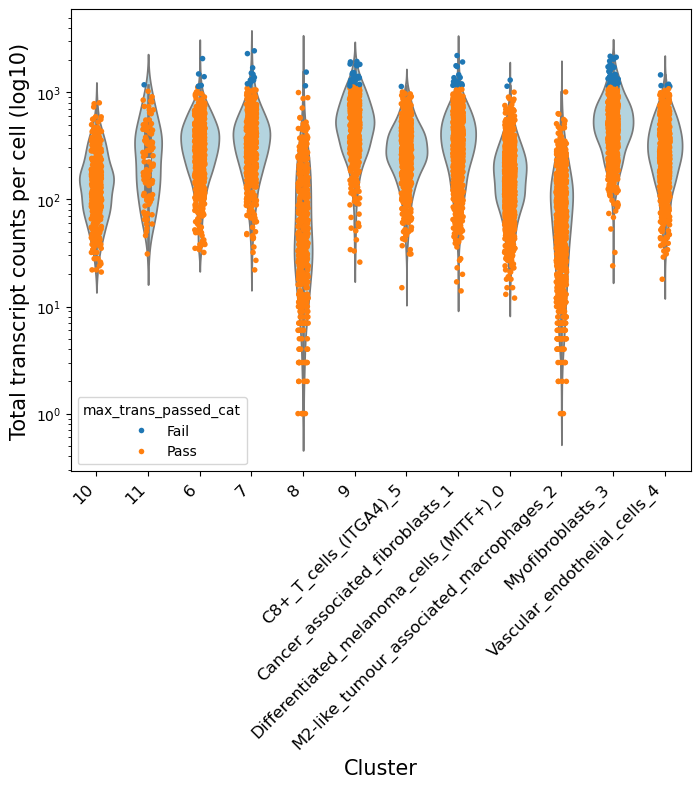

In [25]:


# ---------------------------------------------------------------------------- #
#    CLUSTER LEVEL VIOLIN PLOTS OF MAXIMUM TRANSCRIPT COUNT THRESHOLD CELLS    #
# ---------------------------------------------------------------------------- #

obs = adata_clean.obs
cell_label = cluster_ann_col

plt.figure(figsize=(8, 6))
sns.violinplot(data=obs, y=obs["nCount_Xenium"],  x=obs[cluster_ann_col], log_scale=10, color="lightblue")

sns.stripplot(data=obs, y=obs["nCount_Xenium"], x=obs[cluster_ann_col], hue =obs["max_trans_passed_cat"], size=4)

plt.xlabel("Cluster", fontsize=15)
plt.ylabel("Total transcript counts per cell (log10)", fontsize=15)
plt.xticks(rotation=45, fontsize=12, ha='right', va='top')


plt.savefig(
    os.path.join(qc_path, f"max_transcript_threshold_passed_cells_per_cluster_violin_plot_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )




In [ ]:


# ---------------------------------------------------------------------------- #
#                        TOP EXPRESSED GENES PER CLUSTER                       #
# ---------------------------------------------------------------------------- #
### Spatial clustering results

import scanpy as sc

## Rank genes and identify cluster gene markers
sc.tl.rank_genes_groups(
    adata_clean,
    groupby=cluster_col,
    method='wilcoxon',
    key_added=f"{cluster_col}_markers"
)




In [ ]:


## Using the filter_ranked_genes_by_type to create a key for 
## A key can be generate for the nbr_0 results, which represent markers of neighbour cells not for annotation
## and a key can be generated for nbr_1, where these markers being represents cells that are in a ring interface around given cell
from banksy_utils.annotation_utils import filter_ranked_genes_by_type

key_filtered = filter_ranked_genes_by_type(
    adata_clean,
    key=f"{cluster_col}_markers",
    top_n=100,
    gene_type = "raw",
    new_key_suffix="_raw",
)




In [ ]:


# Plot the gene markers for each cluster
sc.pl.rank_genes_groups(
    adata_clean, 
    key=key_filtered,
    method='wilcoxon',
    n_genes=20, 
    fontsize=15,
    save= f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_spatial_top_gene_raw.png")




In [ ]:


## Total counts across unlabeled clustered
sc.pl.violin(
    adata_clean, 
    "total_counts", 
    groupby=cluster_col, 
    save= f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
    )




In [ ]:


# ---------------------------------------------------------------------------- #
#                                CLUSTER HEATMAP                               #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = output_path

## Generate heat map for top markers per cluster
sc.tl.dendrogram(
    adata_clean,
    groupby=cluster_col,
    key_added=cluster_col
)

## Determine vmin and vmax dynamically based on gene expression.
## Convert matrix-like/sparse values to a plain ndarray so NumPy percentiles
## do not inherit np.matrix multiplication semantics.
expr_values = adata_clean.X
if hasattr(expr_values, "toarray"):
    expr_values = expr_values.toarray()
expr_values = np.asarray(expr_values).ravel()
positive_expr_values = expr_values[expr_values > 0]
if positive_expr_values.size == 0:
    vmax_dynamic = 0
else:
    vmax_dynamic = np.percentile(positive_expr_values, 99)
vmin_dynamic = np.percentile(expr_values, 1)

sc.pl.rank_genes_groups_heatmap(
    adata_clean, 
    key=f"{cluster_col}_markers_raw",
    #key= 'raw_test',
    n_genes=5,
    cmap = "plasma",
    vmin=vmin_dynamic,
    vmax=vmax_dynamic,
    show_gene_labels = True,
    save = f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_raw_markers.png",
    figsize=(20, 15)
)




In [ ]:


# ---------------------------------------------------------------------------- #
#                  GENERATE DENDROGRAM AND CORRELATION MATRIX                  #
# ---------------------------------------------------------------------------- #
groupby_key = cluster_ann_col

sc.tl.dendrogram(adata_clean, groupby=groupby_key)

sc.pl.dendrogram(
    adata_clean,
    groupby=groupby_key,
    save=f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
)

sc.pl.correlation_matrix(
    adata_clean,
    groupby = groupby_key,
    save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_cluster_correlation_plot.png",
    figsize=(5, 3.5)
)




In [ ]:


# ---------------------------------------------------------------------------- #
#                            EXPORT CLUSTER MARKERS                            #
# ---------------------------------------------------------------------------- #
### Export the top 20 clusters in wide format to .csv

from banksy_utils.annotation_utils import export_clusters_wide

key = f"{cluster_col}_markers_raw"

export_clusters_wide(
    adata= adata_clean,
    key= key,
    gene_type= "raw",
    top_n= 20,
    dataset_name= dataset_name,
    file_path= processed_path
)




In [ ]:


# ### Export the top 20 clusters in long format with scores to .csv

from banksy_utils.annotation_utils import export_cluster_markers

export_cluster_markers(
    adata = adata_clean,
    key = key,
    top_n = 20,
    dataset_name = dataset_name,
    file_path = processed_path
)




In [ ]:


# ---------------------------------------------------------------------------- #
#                       ADD CELL TYPE INFO TO TOP MARKERS                      #
# ---------------------------------------------------------------------------- #

## Read in the exported cluster markers generated with "export_clusters_wide()"
## and merge with the cell type annotation master document
n_genes_label =  20 # Set this to the number of genes that were exorted as top markers for each cluster
top_markers = pd.read_csv(f"{processed_path}/cluster_top_{n_genes_label}_genes_with_scores_{dataset_name}_{key}.csv", index_col=0) #index_col = 0 prevents insertion of an unnamed col
top_markers = top_markers.sort_values(by='cluster', ascending=False)
#print(top_markers)

## Read in the master annotation file which contains all the curated cell type labels for each marker gene
#master_markers_file = pd.read_csv(f"{raw_path}/xenium_gene_list_annotation_master.csv")
master_marker_candidates = [
    os.path.join(raw_path, "xenium_gene_list_annotation_master_v1_March_2026_Tier1.csv"),
    os.path.join(base_dir, "raw_data", "xenium_panel_gene_lists", "xenium_gene_list_annotation_master_v1_March_2026_Tier1.csv"),
    os.path.join(base_dir, "raw_data", "gene_markers", "archive", "xenium_gene_list_annotation_master_v1_March_2026_Tier1.csv"),
    os.path.join(base_dir, "raw_data", "gene_markers", "01_xenium_gene_list_annotation_master_v1_May_2026_Tier1_2026-06-15.csv"),
]
master_marker_path = next(
    (candidate for candidate in master_marker_candidates if os.path.isfile(candidate)),
    None,
)
if master_marker_path is None:
    raise FileNotFoundError(
        "Could not find marker annotation master file. Checked: "
        f"{master_marker_candidates}"
    )
print(f"Reading marker annotation master file: {master_marker_path}")
master_markers_file = pd.read_csv(master_marker_path)

## Create a data frame of the genes and their corresponding primary and secondary cell type annotations 
cell_annotations = master_markers_file[["Gene", "primary_annotation", "secondary_annotation"]]
#cell_annotations = cell_annotations.sort_index()

# ## Merge the top marker results and the cell type annotations
# merged_markers = (
#     pd.merge(
#         #top_markers.reset_index(),
#         top_markers.sort_values(by='cluster', ascending=False),
#         cell_annotations, 
#         left_on="gene", 
#         right_on="Gene", 
#         how="left", 
#         sort="False",
#         #validate="m:1"
#     )
#     #.set_index("index")
#     #.loc[top_markers.index]
# )

merged_markers = top_markers.reset_index().merge(
    cell_annotations,
    left_on="gene",
    right_on="Gene",
    how='left'
)
merged_markers['cluster'] = merged_markers['cluster'].astype(int)
merged_markers = merged_markers.sort_values('cluster', ascending=True).reset_index(drop=True)
merged_markers = merged_markers.drop("Gene", axis=1)
print(merged_markers)

## Export the cell type annotated top markers to .csv to use in manual annotation and ChatGPT annotation
merged_markers.to_csv(f"{processed_path}/cell_type_cluster_top_{n_genes_label}_genes_{dataset_name}_{key}.csv")




In [ ]:


#  ---------------------------------------------------------------------------- #
#                        ADD CELL TYPE INFO TO TOP MARKERS                      #
#  ---------------------------------------------------------------------------- #
## The top 20 gene markers for each cluster are assessed for cell cluster annotation
# cluster annotations are stored in cluster_ann_col on adata_clean




In [ ]:


# ---------------------------------------------------------------------------- #
#                        STORE THE UMAP RESULTS IN .OBSM                       #
# ---------------------------------------------------------------------------- #
# This test uses the clean clustered object directly; no old BANKSY dictionary is loaded.




In [ ]:


# ---------------------------------------------------------------------------- #
#                                ANNOTATED UMAP                                #
# ---------------------------------------------------------------------------- #

### Cluster Annotated UMAP
## Plot the umap with bulk labels
import scanpy as sc
from matplotlib.pyplot import rc_context

color_vars = [
cluster_ann_col
]

with rc_context({"figure.figsize": (3,3)}):
    sc.pl.umap(
        adata_clean, 
        color=color_vars, 
        s=50, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=10,
        title=f"{dataset_name} clusters",
        save = f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
        )




In [ ]:


## Plot the umap with bulk labels
color_vars = [
cluster_ann_col
]

fig, axes = plt.subplots(1, 2, figsize=(20,10))

#with rc_context({"figure.figsize": (3,3)}):
sc.pl.umap(
    adata_clean, 
    color=color_vars, 
    s=5, 
    frameon=True, 
    vmax="p99",
    add_outline=True,
    legend_fontsize=10,
    title=f"{dataset_name} clusters",
    ax=axes[0],
    show=False
    #save = f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png",
    )
plt.legend(fontsize=20, title_fontsize=50)

color_vars = [
"min_trans_passed_cat"
]

#with rc_context({"figure.figsize": (3,3)}):
sc.pl.umap(
    adata_clean, 
    color=color_vars, 
    s=5, 
    frameon=True, 
    vmax="p99",
    add_outline=True,
    legend_fontsize=10,
    title=f"{dataset_name} clusters",
    ax=axes[1],
    show=False
    #save = f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png",
    )

plt.tight_layout()
plt.legend(fontsize=20, title_fontsize=50)
plt.savefig(os.path.join(qc_path, f"umap_{dataset_name}_threshold.png"), dpi=300, bbox_inches='tight')
plt.show()




In [ ]:


# ---------------------------------------------------------------------------- #
#                              SET PATHS FOR PLOTS                             #
# ---------------------------------------------------------------------------- #

## Create a path for gene of interest UMAP plots
umap_path = os.path.join(output_path, "umap")

if not os.path.isdir(umap_path):
    os.makedirs(umap_path)
    print(f"Directory '{umap_path}' created successfully.")
    
else:
    print(f"Directory '{umap_path}' already exists.")


## Create a path for gene of interest violin plots
violin_path = os.path.join(output_path, "violin")

if not os.path.isdir(violin_path):
    os.makedirs(violin_path)
    print(f"Directory '{violin_path}' created successfully.")
    
else:
    print(f"Directory '{violin_path}' already exists.")

## Create a path for gene of interest dot plots
dotplot_path = os.path.join(output_path, "dotplot")

if not os.path.isdir(dotplot_path):
    os.makedirs(dotplot_path)
    print(f"Directory '{dotplot_path}' created successfully.")
    
else:
    print(f"Directory '{dotplot_path}' already exists.")

## Create a path for gene of interest UMAP plots
neighbour_path = os.path.join(output_path, "neighbourhood_centrality_co-occurence")

if not os.path.isdir(neighbour_path):
    os.makedirs(neighbour_path)
    print(f"Directory '{neighbour_path}' created successfully.")
    
else:
    print(f"Directory '{neighbour_path}' already exists.")


## Create a path for gene of interest spatial scatter plots
spatial_scatter_path = os.path.join(output_path, "spatial_scatter")

if not os.path.isdir(spatial_scatter_path):
    os.makedirs(spatial_scatter_path)
    print(f"Directory '{spatial_scatter_path}' created successfully.")
    
else:
    print(f"Directory '{spatial_scatter_path}' already exists.")




In [ ]:


# ---------------------------------------------------------------------------- #
#                        GENE OF INTEREST UMAP FUNCTION                        #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = umap_path
def plot_goi_umaps (
    genes: list,
    adata,
    sample_name: str,
    s: int = 20,
    **kwargs #additional sc.pl.umap arguments such as ncols
):
    title_list = []

    for i in genes:
        title = f"{i} expression in {sample_name}"
        title_list.append(title)
        gene_str = "_".join(genes)

    with rc_context({"figure.figsize": (8,5)}):
        sc.pl.umap(
            adata, 
            color=genes, 
            s=20, 
            frameon=True, 
            vmax="p99",
            add_outline=True,
            legend_fontsize=9,
            title=title_list,
            save = f"_{sample_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_{gene_str}_response_genes.png",
            **kwargs
            )




In [ ]:


## DSG2 UMAP
plot_goi_umaps(genes=["DSG2", "TPD52L2"],
adata=adata_clean,
sample_name= dataset_name,
s=20, )




In [ ]:


## SERPINE1 UMAP
plot_goi_umaps(genes=["SERPINE1"],
adata=adata_clean,
sample_name= dataset_name,
s=20, )




In [ ]:


### DKK1

plot_goi_umaps(genes=["DKK1"],
adata=adata_clean,
sample_name= dataset_name,
s=20, )




In [ ]:


### T cell markers

plot_goi_umaps(genes=["FOXP3", "GZMB"],
adata=adata_clean,
sample_name= dataset_name,
s=20, )




In [ ]:


### Integrin genes

plot_goi_umaps(genes=[
"ITGAE", 
"ITGA1", 
"ITGA4",
"ITGA5"],
adata=adata_clean,
sample_name= dataset_name,
s=20,
ncols=2
)




In [ ]:


# ### TPD52 family

plot_goi_umaps(genes=[
"TPD52", 
"TPD52L1", 
"TPD52L2"
],
adata=adata_clean,
sample_name= dataset_name,
s=20,
ncols=2
)




In [ ]:


#### Selectins

plot_goi_umaps(genes=[
"SELE", 
"SELL", 
"SELP"
],
adata=adata_clean,
sample_name= dataset_name,
s=20,
ncols=2
)




In [ ]:


# ### Fucosyltransferase genes

plot_goi_umaps(genes=[
"FUT6", 
"FUT7"
],
adata=adata_clean,
sample_name= dataset_name,
s=20
)




In [ ]:


# ### Adhesion molecules

plot_goi_umaps(genes=[
"VCAM1", 
"ICAM1"
],
adata=adata_clean,
sample_name= dataset_name,
s=20
)




In [ ]:


# ### ICI response genes

plot_goi_umaps(genes=[
"PDCD1", 
"CD274", 
"CTLA4"
],
adata=adata_clean,
sample_name= dataset_name,
s=20
)




In [ ]:


# ---------------------------------------------------------------------------- #
#                         GENE EXPRESSION VIOLIN PLOTS                         #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = violin_path

with rc_context({"figure.figsize": (10, 8)}):
    ax= sc.pl.violin(
        adata_clean,
        ["nFeature_Xenium"],
        groupby=cluster_ann_col,
        rotation=270,
        stripplot=False,  # remove the internal dots
        inner="box",  # adds a boxplot inside violins
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_gene_count_per_cluster_violin_plot.png"
    )




In [ ]:


#### DSG2

with rc_context({"figure.figsize": (10,8)}):
   ax = sc.pl.violin(
        adata_clean, 
        keys = [
            "DSG2"
            ], 
        #groupby=cluster_col,
        groupby=cluster_ann_col,
        rotation=270,
        #save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )
ax.set_yscale('log')
ax.set_xlabel('Cell type', fontsize=12)
ax.set_ylabel("DSG2 expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_DSG2_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)




In [ ]:


#### SERPINE1

with rc_context({"figure.figsize": (10,8)}):
   ax = sc.pl.violin(
        adata_clean, 
        keys = [
            "SERPINE1"
            ], 
        groupby=cluster_ann_col,
        rotation=270,
        #save=f"{dataset_name}_pc{pc_label_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )
ax.set_yscale('log')
ax.set_xlabel('Cell type', fontsize=12)
ax.set_ylabel("SERPINE1 expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_SERPINE1_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)




In [ ]:


#### DKK1

with rc_context({"figure.figsize": (10,8)}):
   ax = sc.pl.violin(
        adata_clean, 
        keys = [
            "DKK1"
            ], 
        groupby=cluster_ann_col,
        rotation=270,
        #save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )
ax.set_yscale('log')
ax.set_xlabel('Cell type', fontsize=12)
ax.set_ylabel("DKK1 expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_DKK1_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)




In [ ]:


#### T cell markers

with rc_context({"figure.figsize": (10,8)}):
   axes = sc.pl.violin(
        adata_clean, 
        keys = [
             "FOXP3", 
             "GZMB"
            ], 
        #groupby=cluster_col,
        groupby=cluster_ann_col,
        rotation=270,
        #save=f"{dataset_name}_pc{pc_label_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )

# Apply customisation to each graph axis
for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('Cell type', fontsize=12)

axes[0].set_ylabel("T cell markers expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_T_cell_markers_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)




In [ ]:


#### Integrins

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata_clean, 
        [
            "ITGAE", 
            "ITGA1", 
            "ITGA4",
            "ITGA5"
            ], 
        #groupby=cluster_col,
        groupby=cluster_ann_col,
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_integrin_genes_violin_plot.png"
        )




In [ ]:


#### TPD52 genes

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata_clean, 
        [
            "TPD52",
            "TPD52L1",
            "TPD52L2"
            ], 
        groupby=cluster_ann_col,
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_TPD52_genes_violin_plot.png"
        )




In [ ]:


##### Selectins

with rc_context({"figure.figsize": (6,5)}):
    sc.pl.violin(
        adata_clean, 
        [
        "SELE", 
        "SELL", 
        "SELP"
        ], 
        groupby=cluster_ann_col,
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_selectin_genes_violin_plot.png"
        )




In [ ]:


#### Fucosyltransferase genes

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata_clean, 
        [
            "FUT6", 
            "FUT7"
        ], 
        groupby=cluster_ann_col,
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_fucosyltransferase_genes_violin_plot.png"
        )




In [ ]:


# ### Adhesion genes

with rc_context({"figure.figsize": (6,5 )}):
    sc.pl.violin(
        adata_clean, 
        [
            "VCAM1",
            "ICAM1"
        ], 
        groupby=cluster_ann_col,
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_adhesion_genes_violin_plot.png"
        )




In [ ]:


# ### ICI response genes

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata_clean, 
        [
            "PDCD1", 
            "CD274", 
            "CTLA4"
        ], 
        groupby=cluster_ann_col,
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_adhesion_genes_violin_plot.png"
        )




In [ ]:


# ---------------------------------------------------------------------------- #
#                           Gene expression dot plots                          #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = dotplot_path
adata_clean.obs[cluster_ann_col]




In [ ]:


# --------------------------- Top 20 gene dotplots --------------------------- #

## cycle through the cluster labels and create dotplot for each element
from banksy_utils.annotation_utils import extract_marker_genes_dict

## Ensure that the patch line edge colopur is set to black in global matplotlib rcparams so that the bracket to group genes per cluster is shown
plt.rcParams['patch.edgecolor'] = 'black'

cluster_keys = list(new_labels.keys())
values = list(new_labels.values())

## Compute the dendrogram for clusters
sc.tl.dendrogram(
    adata_clean,
    groupby=cluster_ann_col
    )

for i in range(len(cluster_keys)):
    key = cluster_keys[i]
    subset_cluster= new_labels[key]
    cluster_label = values[i]


    marker_genes_dict=extract_marker_genes_dict(
    adata=adata_clean, 
    filtered_key=key_filtered, 
    gene_type='raw', 
    groupby = cluster_ann_col,
    subset_cluster= subset_cluster,
    top_n=20
    )
    marker_genes_dict

    # Skip if no marker genes found
    if not marker_genes_dict or all(len(v) == 0 for v in marker_genes_dict.values()):
        print(f"Skipping {cluster_label} — no marker genes found")
        continue

## Generate dot plot
    with rc_context({"figure.figsize": (10,10)}):
        sc.pl.dotplot(
            adata_clean, 
            #marker_genes_list,
            marker_genes_dict,
            groupby=cluster_ann_col,
            #dendrogram=True,
            save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_{cluster_label}_dot_plot.png"
            )




In [ ]:


# --------------------------- Tier gene 1 dotplots --------------------------- #

#### Dot plot function
def plot_goi_dotplot (
    adata,
    cell_type_savename: str,
    marker_genes_dict: dict, #dictionary such as {"Melanoma : ['TYR', 'EDNRB']"}
    s: int = 20,
    **kwargs #additional sc.pl.umap arguments such as ncols or dendrogram = True
):

    with rc_context({"figure.figsize": (10,10)}):
        sc.pl.dotplot(
            adata, 
            marker_genes_dict,
            groupby=cluster_ann_col,
            save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_{cell_type_savename}_dot_plot.png",
            **kwargs
            )




In [ ]:


# Set the figure directory to your desired location
sc.settings.figdir = dotplot_path




In [ ]:


#### B cell Tier 1 dotplot
B_cell_markers = {"B_cells" : [
"CD79A",
"LTB",
"MEF2C",
"MZB1",
"PKHD1L1",
"TNFRSF17",
"CD274"]
}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "B_cells_Tier_1",
    marker_genes_dict= B_cell_markers
)




In [ ]:


#### Cycling cell dotplot
cycling_cell_marker = {"Cycling_Cells_Tier_1" : [
"BIRC5",
"CDC20",
"CDK1",
"CENPF",
"HIST1H4C",
"HMGB2",
"MKI67",
"NUSAP1",
"PTTG1",
"RRM2",
"STMN1",
"TOP2A",
"TYMS",
"UBE2C"
]
}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Cycling_Cells_Tier_1",
    marker_genes_dict= cycling_cell_marker
)




In [ ]:


#### Cycling cell dotplot
dendritic_cell_marker = {"Dendritic_Cells_Tier_1" : [
"AXL",
"BIRC3",
"CBFA2T3",
"CCR7",
"CLEC10A",
"CLEC9A",
"ENPP1",
"FCER1A",
"FSCN1",
"GPR157",
"ID2",
"IDO1",
"IL3RA",
"IL4I1",
"IRF8",
"MARCKSL1",
"MNDA",
"PKIB",
"RGCC",
"S100B",
"SLC8A1",
"SYNPO2",
"TFPI2",
"TMEM150C",
"TMEM176A",
"TUBB2B",
"WDFY4",
"CD1A",
"CD1B",
"CLDN1",
"PTGER3"
]
}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Dendritic_Cells_Tier_1",
    marker_genes_dict= dendritic_cell_marker
)




In [ ]:


#### Eccrine dotplot
eccrine_cell_marker = {"Eccrine_Tier_1" : [
"CLDN4",
"KRT18"
]
}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Eccrine_Tier_1",
    marker_genes_dict= eccrine_cell_marker
)




In [ ]:


#### Erythrocyte dotplot
erythrocyte_cell_marker = {"Erythrocyte_Tier_1" : [
"FAM210B",
"FBXO7",
"FKBP8",
"GYPC",
"HBD",
"SLC25A37",
"SLC25A39",
"SNCA",
"STRADB"
]
}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Erythrocyte_Tier_1",
    marker_genes_dict= erythrocyte_cell_marker
)




In [ ]:


#### Fibroblast dotplot
fibroblast_cell_marker = {"Fibroblast_Tier_1" : [
"ADAM12",
"AKR1C1",
"APCDD1",
"APOD",
"ASPN",
"CCL19",
"COCH",
"COL5A2",
"COL6A1",
"COL6A2",
"COL6A3",
"CXCL12",
"FBLN1",
"GEM",
"HAPLN1",
"HTRA1",
"IGFBP2",
"IGFBP5",
"LEPR",
"LSAMP",
"LUM",
"MFAP4",
"MFAP5",
"MGP",
"MMP2",
"MMP27",
"PDGFRA",
"PLAC9",
"POSTN",
"PTGDS",
"SFRP2",
"SLPI",
"SOD3",
"THBS2",
"THY1",
"VIM",
"DKK1",
"ITGA5"
]
}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Fibroblast_Tier_1",
    marker_genes_dict= fibroblast_cell_marker
)




In [ ]:


#### Fibroblast dotplot
keratinocyte_cell_marker = {"Keratinocyte_Tier_1" : [
"ACER1",
"AHNAK2",
"AQP3",
"AREG",
"COL17A1",
"CXADR",
"DEFB1",
"DSC1",
"ENAH",
"FGFBP1",
"HES1",
"IGFBP3",
"IL33",
"LAMB3",
"LY6D",
"MAL2",
"MT1X",
"PCDH7",
"PTGR1",
"RHOV",
"S100A13",
"S100A14",
"SERPINB5",
"SFRP1",
"SOX15",
"DSC2",
"DSG1",
"DSG3",
"GALNT6",
"DST",
"ITGA6",
"ITGB1",
"KRT15",
"KRT5",
"MIR205HG",
"SERPINB2",
"TACSTD2",
"TFAP2A",
"TP63",
"KRTDAP",
"LYPD3",
"KRT2",
"NOTCH3"
]
}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Keratinocyte_Tier_1",
    marker_genes_dict= keratinocyte_cell_marker
)




In [ ]:


#### Lymphatic endothelial cells
lymphatic_endothelial_cell_marker = {"Lymphatic_endothelial_Tier_1" : [
"CALCRL",
"ECSCR",
"FABP4",
"LINC00636",
"LYVE1",
"MMRN1",
"PROX1",
"TFPI"

]
}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Lymphatic_endothelial_cell_Tier_1",
    marker_genes_dict= lymphatic_endothelial_cell_marker
)




In [ ]:


#### Macrophage endothelial cells
macrophage_cell_marker = {"Macrophage_Tier_1" : [
"AIF1",
"C5AR1",
"IL1B",
"IRF4",
"CCL3",
"CCL4",
"NOS2",
"TNF",
"CD163",
"CXCL16",
"MRC1",
"BASP1",
"C15orf48",
"C1QA",
"C1orf54",
"CCL22",
"CD68",
"CD83",
"COTL1",
"CPVL",
"CTSZ",
"FCER1G",
"GPR183",
"HMGN2",
"INHBA",
"INSIG1",
"LGALS2",
"LST1",
"LYZ",
"RGS1",
"TSPAN33",
"TYROBP",
"MMP9"
]
}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Macrophage_Tier_1",
    marker_genes_dict= macrophage_cell_marker
)




In [ ]:


#### Melanocyte cells
melanocyte_cell_marker = {"Melanocytes_Tier_1" : [
"BCAN",
"CRYAB",
"CYB561A3",
"DCT",
"EDNRB",
"FRZB",
"MLANA",
"NSG1",
"PMEL",
"QPCT",
"TFAP2B",
"TRPM1",
"TYR",
"TYRP1",
]
}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Melanocytes_Tier_1",
    marker_genes_dict= melanocyte_cell_marker
)




In [ ]:


#### Melanocyte cells
melanoma_cell_marker = {"Melanoma_Tier_1" : [
"ATF3",
"CCND1",
"MITF",
"MYC",
"PLP1",
"DSG2",
"EIF4E",
"ICAM1",
"ID1",
"PRAME",
"SERPINE1",
"TPD52",
"TPD52L1",
"TPD52L2",
]
}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Melanoma_Tier_1",
    marker_genes_dict= melanoma_cell_marker
)




In [ ]:


#### Myofibroblast cells
myofibroblast_cell_marker = {"Myofibroblast_Tier_1" : [
"CALD1",
"GPR4",
"IGFBP7",
"MYL9",
"NDUFA4L2",
"TAGLN"
]
}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Myofibroblast_Tier_1",
    marker_genes_dict= myofibroblast_cell_marker
)




In [ ]:


#### NK cells
nk_cell_marker = {"NK_Tier_1" : [
"CTSW",
"KLRB1",
"ZNF667-AS1"
]
}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "NK_Tier_1",
    marker_genes_dict= nk_cell_marker
)




In [ ]:


#### Pericytes
pericyte_marker = {"Pericyte_Tier_1" : [
"C11orf96",
"CPE",
"ID4",
"IFITM1",
"NR2F2",
"RGS5",
"ACTA2",
"MYH11"
]

}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Pericyte_Tier_1",
    marker_genes_dict= pericyte_marker
)




In [ ]:


#### Pilosebaceous Cells
pilosebaceous_marker = {"Pilosebaceous_cells_Tier_1" : [
"CAPNS2",
"CRABP2",
"PTN",
"SOSTDC1",
"TMEM45A"
]

}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Pilosebaceous_cells_Tier_1",
    marker_genes_dict= pilosebaceous_marker
)




In [ ]:


#### T Cells
T_cell_marker = {"T_cells_Tier_1" : [
"IL2RA",
"ENTPD1",
"FOXP3",
"ALOX5AP",
"ARHGDIB",
"BHLHE41",
"CD3D",
"CD3E",
"CD3G",
"CD40LG",
"CD52",
"CD69",
"CD8A",
"CES1",
"CXCR4",
"DUSP2",
"GATA2",
"GIMAP7",
"GZMK",
"IFNG",
"IL32",
"ITM2A",
"KIT",
"LCK",
"LENG8",
"MT1F",
"NLGN4Y",
"NMB",
"NR4A2",
"PBXIP1",
"PTPRCAP",
"RASSF8",
"SLC2A3",
"CCL5",
"CCR5",
"CD28",
"CD4",
"CTLA4",
"CXCR6",
"FUT6",
"FUT7",
"GZMB",
"ITGA1",
"ITGA4",
"ITGAE",
"PDCD1",
"TCF7",
]

}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "T_cells_Tier_1",
    marker_genes_dict= T_cell_marker
)




In [ ]:


#### Vascular endothelial cells
vascular_endothelial_cell_marker = {"Vascular_endothelial_cells_Tier_1" : [
"AQP1",
"CD93",
"CDH5",
"CLDN5",
"GNG11",
"IFI27",
"MYCT1",
"PLVAP",
"RAMP2",
"RNASE1",
"SELE",
"SOX17",
"SPARCL1",
"SPRY1",
"TFF3",
"TM4SF1",
"TSC22D1",
"VWF",
"SELL",
"SELP",
"VCAM1",
"VEGFA",
]

}

plot_goi_dotplot(
    adata= adata_clean,
    cell_type_savename= "Vascular_endothelial_cell_marker_1",
    marker_genes_dict= vascular_endothelial_cell_marker
)




In [ ]:


# ---------------------------------------------------------------------------- #
#                       NEIGHBOURHOOD ENRICHMENT ANALYSIS                      #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = neighbour_path




In [ ]:


# Adding spatial coordinates to .obsm
adata_clean.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy()




In [ ]:


sq.gr.spatial_neighbors(adata_clean)

cluster_key = cluster_ann_col
sq.gr.nhood_enrichment(adata_clean, cluster_key=cluster_key)

with rc_context({"figure.figsize": (10,10)}):
    sq.pl.nhood_enrichment(
        adata_clean, 
        cluster_key=cluster_key,
        save=f"neighbourhood_enrichment_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png")




In [ ]:


# ---------------------------------------------------------------------------- #
#                      MORAN'S I SCORE OF AUTOCORRELATION                      #
# ---------------------------------------------------------------------------- #

from spatialdata import SpatialData
adata_clean.obs.rename(columns={"cell type": "cell_type"}, inplace=True)

# Create SpatialData with a single table (the AnnData)
sdata = SpatialData(tables={"cells": adata_clean})

# Perform Moran's I calculation
sdata.tables["subsample"] = sc.pp.subsample(adata_clean, fraction=0.5, copy=True)
adata_subsample = sdata.tables["subsample"]

sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns["moranI"].head(10)




In [ ]:


## Store moran I scores as a data frame
moran_scores = adata_subsample.uns["moranI"]
moran_scores = moran_scores.reset_index(names=["Gene"])

## Exclude _nbr_0 and _nbr_1
moran_scores_raw = moran_scores[~moran_scores["Gene"].str.contains("_nbr_0", case=False, na=False)]
moran_scores_raw = moran_scores_raw[~moran_scores_raw["Gene"].str.contains("_nbr_1", case=False, na=False)]

## Filter for genes that have an FDR if less than 10%
moran_scores_raw = moran_scores_raw[moran_scores_raw["pval_sim_fdr_bh"] <= 0.10]

## Write Moran I scores to .csv
moran_scores_raw.to_csv(f"{processed_path}/moran_scores_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.csv")




In [ ]:


## Plot spatial scatter plots for genes with the top 10 highest Moran I scores

## Create a list of the top scoring genes
top_moran = moran_scores_raw.sort_values(by="pval_sim", ascending=True)
top_moran = top_moran.iloc[:10]
top_moran = list(top_moran['Gene'])
top_moran

for i in top_moran:
    with rc_context({"figure.figsize": (12,8)}):
        sq.pl.spatial_scatter(
            adata_subsample,
            library_id="spatial",
            color=[i],
            shape=None,
            size=2,
            img=False,
            save= f"spatial_scatter_top_moran_I_{i}_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
)




In [ ]:


# ###############################################
# #       COMPUTE AND PLOT CENTRALITY SCORE     #
# ###############################################
# # ## Compute centrality scores
# sq.gr.centrality_scores(adata_subsample, cluster_key=cluster_key)
# sq.pl.centrality_scores(adata_subsample, cluster_key=cluster_key, figsize=(22, 4))

# ### Compute co-occurence probability
# from spatialdata import SpatialData
# sdata = SpatialData()
# sdata.tables["subsample"] = sc.pp.subsample(adata_subsample, fraction=0.5, copy=True)
# cluster_keys = list(new_labels.keys())

# cluster_key_label = cluster_col

# ## Calculate and plot the co-occurence of clusters
# sq.gr.co_occurrence(
#     adata_subsample,
#     cluster_key=cluster_key_label
#     )


# for i in cluster_keys:     
#     cluster_number = str(i)
     
#     with rc_context({"figure.figsize": (12,12)}):
#         sq.pl.co_occurrence(
#             adata_subsample,
#             cluster_key=cluster_key_label,
#             clusters=i,
#             figsize=(10, 10),
#             save=f"co-occurence_cluster_{cluster_number}_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
#             )

# with rc_context({"figure.figsize": (12,8)}):
#     sq.pl.spatial_scatter(
#         adata_subsample,
#         library_id="dataset_name",
#         color=cluster_key_label,
#         shape=None,
#         size=2,
#         save=f"spatial_cluster_scatter_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
#         )




In [ ]:


# ---------------------------------------------------------------------------- #
#                   SPATIAL EXPRESSION FOR GENES OF INTEREST                   #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = spatial_scatter_path

goi_list = [
    "DSG2",
    "SERPINE1",
    "DKK1",
    "FOXP3", 
    "GZMB",
    "ITGAE",
    "ITGA1",
    "ITGA4",
    "ITGA5",
    "TPD52",
    "TPD52L1",
    "TPD52L2",
    "SELE", 
    "SELL", 
    "SELP",
    "FUT6", 
    "FUT7",
    "VCAM1",
    "ICAM1",
    "PDCD1", 
    "CD274", 
    "CTLA4",
]

# Set the figure directory to your desired location
sc.settings.figdir = spatial_scatter_path

for gene in goi_list:
    sq.pl.spatial_scatter(
        adata_subsample,
        library_id="spatial",
        color=[gene],
        shape=None,
        size=2,
        img=False,
        save= f"spatial_scatter_{gene}_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
)

